In [90]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/hiteshyadavx/employee-salary/employee_income.csv


In [91]:
df = pd.read_csv('/kaggle/input/datasets/hiteshyadavx/employee-salary/employee_income.csv')
df.head()

,age,experience,income
0,50,5,45118
1,36,9,41691
2,29,3,35994
3,42,5,41614
4,40,12,51474


In [92]:
X , y = df.drop(columns=['income']) , df['income']
print(X[:2])
print(y[:2])

   age  experience
0   50           5
1   36           9
0    45118
1    41691
Name: income, dtype: int64


In [93]:
print(df.columns)

Index(['age', 'experience', 'income'], dtype='object')


In [94]:
print(df.isnull().sum())

age           0
experience    0
income        0
dtype: int64


In [95]:
df.shape

(50, 3)

In [96]:
X_data = np.array(X)
y_data = np.array(y).reshape(-1,1)
print(X_data[:2])
print(y_data[:2])

[[50  5]
 [36  9]]
[[45118]
 [41691]]


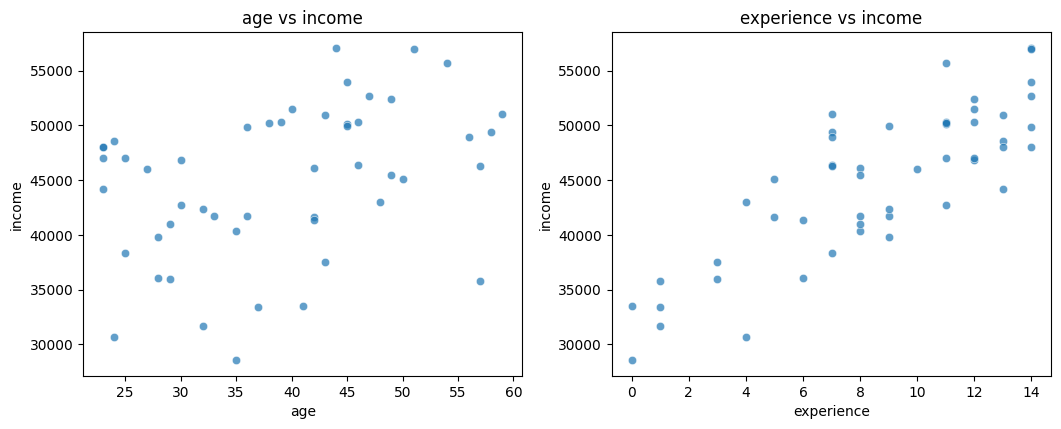

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

input = ['age', 'experience']

plt.figure(figsize=(16, 12))

for i, col in enumerate(input):
    plt.subplot(3, 3, i + 1)
    sns.scatterplot(data=df, x=col, y='income', alpha=0.7)
    plt.title(f'{col} vs income')

plt.tight_layout()
plt.show()

In [98]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train,X_test,y_train,y_test = train_test_split(X_data,y_data,test_size=0.2,random_state=42)

Scaler_X = StandardScaler()
Scaler_y = StandardScaler() 

X_train_scale = Scaler_X.fit_transform(X_train)
X_test_scale = Scaler_X.transform(X_test)
y_train_scale = Scaler_y.fit_transform(y_train)
y_test_scale = Scaler_y.transform(y_test)

print(X_train_scale[:2])
print(y_train_scale[:2])

[[ 0.31030163 -1.39748016]
 [ 0.03033023  0.96445814]]
[[-1.04034643]
 [ 1.00857133]]


In [99]:
import torch

X_train_scale_tensor = torch.tensor(X_train_scale, dtype = torch.float32)
X_test_scale_tensor = torch.tensor(X_test_scale, dtype = torch.float32)
y_train_scale_tensor = torch.tensor(y_train_scale, dtype = torch.float32)
y_test_scale_tensor = torch.tensor(y_test_scale, dtype = torch.float32)

print(X_train_scale_tensor[:2])
print(y_train_scale_tensor[:2])

tensor([[ 0.3103, -1.3975],
        [ 0.0303,  0.9645]])
tensor([[-1.0403],
        [ 1.0086]])


In [100]:
print(X_data.shape[1])

2


In [101]:
import torch.nn as nn
import torch.optim as optim

class SalaryPredictor(nn.Module):
    def __init__(self,input_dim):
        super(SalaryPredictor,self).__init__()
        self.layer1 = nn.Linear(input_dim,8)
        self.output = nn.Linear(8,1)
        self.relu = nn.ReLU()
    def forward(self,x):
        x = self.relu(self.layer1(x))
        x = self.output(x)
        return x 



input_dim = X_data.shape[1]
model = SalaryPredictor(input_dim)

loss_fun = nn.MSELoss()
optimizer = optim.SGD(model.parameters(),lr=0.01)

epochs = 1000
for epoch in range(epochs):
    model.train()
    output = model(X_train_scale_tensor)
    loss = loss_fun(output,y_train_scale_tensor)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    if epoch % 100 == 0:
        print(loss.item())


from sklearn.metrics import r2_score,mean_absolute_error

model.eval()
with torch.no_grad():
    output = model(X_test_scale_tensor)
    r2 = r2_score(y_test_scale_tensor,output)
    mae = mean_absolute_error(y_test_scale_tensor,output)

print(f"r2_score : {r2}")
print(f"mae : {mae}")

0.8241115808486938
0.15037712454795837
0.09240511804819107
0.08855292201042175
0.08679655939340591
0.08564401417970657
0.08466409146785736
0.08378227800130844
0.08303073793649673
0.08223667740821838
r2_score : 0.9135810171138838
mae : 0.22555228509008884


In [102]:
# import torch.nn as nn
# import torch.optim as optim

# class SalaryPredictor(nn.Module):
#     def __init__(self,input_dim):
#         super().__init__()
        
        